In [23]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [24]:
(x_train,y_train), (x_test,y_test) = imdb.load_data(num_words=10000)


x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

In [25]:
model = Sequential()
model.add(Embedding(10000,32, input_length=100))
model.add(SimpleRNN(5,return_sequences=True))
model.add(SimpleRNN(5))
model.add(Dense(1,activation="sigmoid"))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 100, 32)           320000    
                                                                 
 simple_rnn_6 (SimpleRNN)    (None, 100, 5)            190       
                                                                 
 simple_rnn_7 (SimpleRNN)    (None, 5)                 55        
                                                                 
 dense_3 (Dense)             (None, 1)                 6         
                                                                 
Total params: 320,251
Trainable params: 320,251
Non-trainable params: 0
_________________________________________________________________


In [26]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics='accuracy')

In [27]:
from keras.callbacks import EarlyStopping
callback = EarlyStopping(monitor="loss", patience=2,restore_best_weights=True)

In [28]:
history = model.fit(x_train,y_train, epochs=5, batch_size=32, validation_split=0.25, callbacks=callback)

Epoch 1/5
586/586 [==============================] - 101s 170ms/step - loss: 0.6784 - accuracy: 0.5550 - val_loss: 0.6545 - val_accuracy: 0.5904
Epoch 2/5
586/586 [==============================] - 106s 180ms/step - loss: 0.5641 - accuracy: 0.7069 - val_loss: 0.6756 - val_accuracy: 0.6131
Epoch 3/5
586/586 [==============================] - 129s 221ms/step - loss: 0.3604 - accuracy: 0.8491 - val_loss: 0.6372 - val_accuracy: 0.7011
Epoch 4/5
586/586 [==============================] - 117s 199ms/step - loss: 0.2174 - accuracy: 0.9195 - val_loss: 0.6848 - val_accuracy: 0.7198
Epoch 5/5
586/586 [==============================] - 116s 198ms/step - loss: 0.1414 - accuracy: 0.9509 - val_loss: 0.8145 - val_accuracy: 0.7045


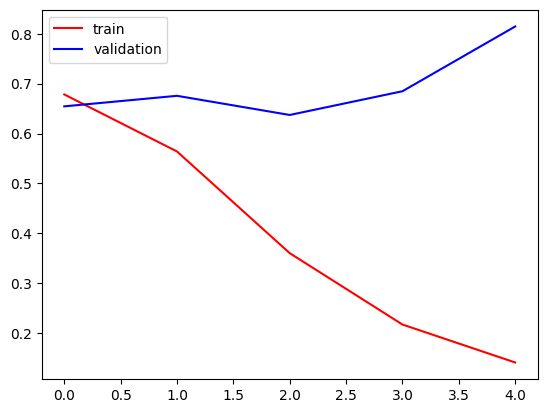

In [29]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

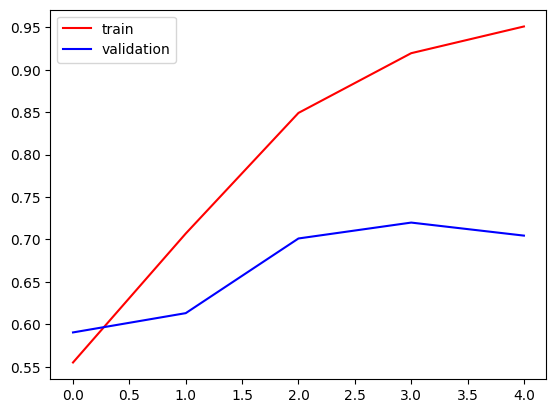

In [31]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()